### Quantitative Analyse der sechs Wahlprogramme

---

In [ ]:
# pip install pyarrow

#### 1. Datensatz einlesen und aufbereiten

In [23]:
import pandas as pd

# Datei einlesen
df = pd.read_parquet("all_parties_text_combined.parquet")

# Erste Zeilen anzeigen
df.head()


,Party,Chapter,These,Text
0,spd,Worauf es jetzt ankommt,None,Am 23. Februar findet die vorgezogene Bundesta...
1,spd,Ein neuer Aufschwung für Deutschland,None,Viele Menschen machen sich derzeit Sorgen um d...
2,spd,1. Wir kämpfen für neues Wachstum und sichere ...,None,"Dies ist das erste, aber sicher nicht das letz..."
3,spd,1. Wir kämpfen für neues Wachstum und sichere ...,Wir wollen Energiepreise senken und zentrale E...,"Wir brauchen bezahlbare Energie, sonst geht un..."
4,spd,1. Wir kämpfen für neues Wachstum und sichere ...,"Wir wollen, dass Unternehmen die besten Rahmen...",Wir können etwas tun für unsere Unternehmen un...


In [24]:
# sofern die Spalte "These" leer ist, wird dort die Hauptüberschrift aus der Spalte "Chapter" eingefügt

df_modified = df.copy()
df_modified["These"] = df_modified["These"].replace("", pd.NA).fillna(df_modified["Chapter"])

In [25]:
df_modified.head()

,Party,Chapter,These,Text
0,spd,Worauf es jetzt ankommt,Worauf es jetzt ankommt,Am 23. Februar findet die vorgezogene Bundesta...
1,spd,Ein neuer Aufschwung für Deutschland,Ein neuer Aufschwung für Deutschland,Viele Menschen machen sich derzeit Sorgen um d...
2,spd,1. Wir kämpfen für neues Wachstum und sichere ...,1. Wir kämpfen für neues Wachstum und sichere ...,"Dies ist das erste, aber sicher nicht das letz..."
3,spd,1. Wir kämpfen für neues Wachstum und sichere ...,Wir wollen Energiepreise senken und zentrale E...,"Wir brauchen bezahlbare Energie, sonst geht un..."
4,spd,1. Wir kämpfen für neues Wachstum und sichere ...,"Wir wollen, dass Unternehmen die besten Rahmen...",Wir können etwas tun für unsere Unternehmen un...


In [26]:
# Nummerierungen entfernen

df_modified["These"] = df_modified["These"].str.replace(r"^\d+\.\s*", "", regex=True)

# df_modified.to_csv("all_parties_text_combined_modified.csv", index=False, encoding="utf-8-sig")

df_modified.head()



,Party,Chapter,These,Text
0,spd,Worauf es jetzt ankommt,Worauf es jetzt ankommt,Am 23. Februar findet die vorgezogene Bundesta...
1,spd,Ein neuer Aufschwung für Deutschland,Ein neuer Aufschwung für Deutschland,Viele Menschen machen sich derzeit Sorgen um d...
2,spd,1. Wir kämpfen für neues Wachstum und sichere ...,Wir kämpfen für neues Wachstum und sichere Arb...,"Dies ist das erste, aber sicher nicht das letz..."
3,spd,1. Wir kämpfen für neues Wachstum und sichere ...,Wir wollen Energiepreise senken und zentrale E...,"Wir brauchen bezahlbare Energie, sonst geht un..."
4,spd,1. Wir kämpfen für neues Wachstum und sichere ...,"Wir wollen, dass Unternehmen die besten Rahmen...",Wir können etwas tun für unsere Unternehmen un...


In [27]:
# Spalte "Chapter" entfernen
df_modified = df_modified.drop(columns=["Chapter"])
df_modified.head()


,Party,These,Text
0,spd,Worauf es jetzt ankommt,Am 23. Februar findet die vorgezogene Bundesta...
1,spd,Ein neuer Aufschwung für Deutschland,Viele Menschen machen sich derzeit Sorgen um d...
2,spd,Wir kämpfen für neues Wachstum und sichere Arb...,"Dies ist das erste, aber sicher nicht das letz..."
3,spd,Wir wollen Energiepreise senken und zentrale E...,"Wir brauchen bezahlbare Energie, sonst geht un..."
4,spd,"Wir wollen, dass Unternehmen die besten Rahmen...",Wir können etwas tun für unsere Unternehmen un...


In [28]:
print(len(df_modified))

625


In [29]:
# Leere Zeilen entfernen
df_modified = df_modified[df_modified["These"].notna()]
print(len(df_modified))

624


#### 2. Wortanzahl

In [30]:
# Fehlende Werte durch leere Strings ersetzen, um Fehler zu vermeiden
# df_modified["These"] = df_modified["These"].fillna("")
# df_modified["Text"] = df_modified["Text"].fillna("")

# Wortanzahl in den Spalten berechnen
df_modified["These_Word_Count"] = df_modified["These"].str.split().str.len()
df_modified["Text_Word_Count"] = df_modified["Text"].str.split().str.len()
df_modified["Total_Word_Count"] = df_modified["These"].str.split().str.len() + df_modified["Text"].str.split().str.len()

# Gruppieren nach 'Party' und Summen berechnen
word_counts = df_modified.groupby("Party")[["These_Word_Count", "Text_Word_Count", "Total_Word_Count"]].sum()

# Ergebnis ausgeben
print(word_counts)


        These_Word_Count  Text_Word_Count  Total_Word_Count
Party                                                      
afd                  381            19015             19396
cdu                  497            21408             21905
fdp                  685            17841             18526
gruene               742            11954             12696
linke                432            29497             29929
spd                  840            25149             25989


#### 3. Satzanzahl

In [31]:
# Anzahl der Wörter pro Text berechnen
df_modified['Text_Word_Count'] = df_modified['Text'].str.split().str.len()

# Gesamtanzahl der Wörter pro Partei berechnen
gesamt_woerter_pro_party = df_modified.groupby('Party')['Text_Word_Count'].sum().reset_index(name='gesamt_woerter')

# Anzahl der Sätze in der Spalte 'text' zählen
anzahl_saetze_text = df_modified.groupby('Party')['Text'].apply(
    lambda x: x.str.cat(sep=' ').count('.') + x.str.cat(sep=' ').count('!') + x.str.cat(sep=' ').count('?')
).reset_index(name='anzahl_saetze')

# Beide DataFrames zusammenführen
result = gesamt_woerter_pro_party.merge(anzahl_saetze_text, on='Party')

# Durchschnittliche Wörter pro Satz berechnen (Division durch 0 vermeiden)
result['durchschn_woerter_pro_satz'] = result['gesamt_woerter'] / result['anzahl_saetze'].replace(0, 1)

print(result)


    Party  gesamt_woerter  anzahl_saetze  durchschn_woerter_pro_satz
0     afd           19015           1263                   15.055424
1     cdu           21408           2040                   10.494118
2     fdp           17841           1245                   14.330120
3  gruene           11954            750                   15.938667
4   linke           29497           2089                   14.120153
5     spd           25149           1621                   15.514497


#### 4. Word-Clouds

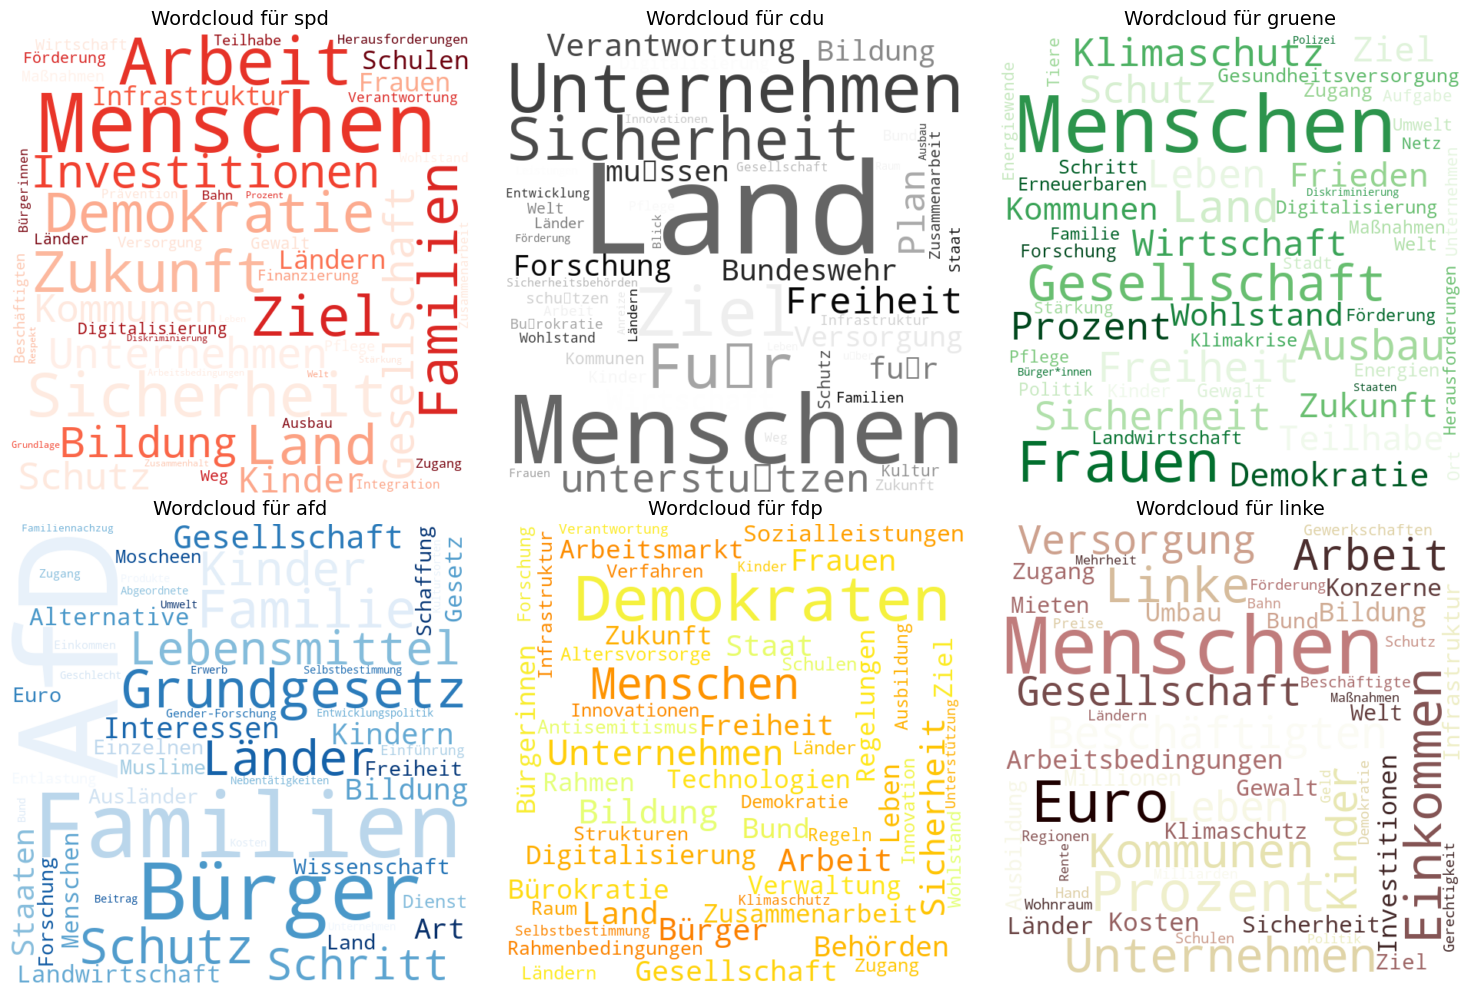

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import spacy
from spacy.lang.de.stop_words import STOP_WORDS
from collections import Counter

# Lade das deutsche Sprachmodell für die POS-Tagging-Analyse
nlp = spacy.load("de_core_news_sm")

# Stopwords erweitern
additional_stopwords = {
    "kapitel", "seite"
}  # Eigene Stopwords hier hinzufügen
stopwords = STOP_WORDS.union(additional_stopwords)

def extract_nouns(text):
    """Extrahiert alle Substantive aus einem Text (inkl. Original-Schreibweise)."""
    doc = nlp(text)  # Verarbeite den Text mit spaCy
    nouns = [token.text for token in doc if token.pos_ == "NOUN" and token.text.lower() not in stopwords]
    return nouns

# Parteien extrahieren
parties = df_modified['Party'].unique()
num_parties = len(parties)

# Matplotlib-Subplots für 2x3-Grid erstellen
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 Zeilen, 3 Spalten, große Figur
axes = axes.flatten()  # Damit wir einfach auf jedes Subplot zugreifen können

# Liste der gezielten Farbschemata
colormaps = ['Reds', 'Greys', 'Greens', 'Blues', 'Wistia_r', 'pink_r']  # Rot, Schwarz, Grün, Blau, Gelb, Dunkelrot

# Wordclouds für jede Partei generieren und im Raster anzeigen
for i, party in enumerate(parties):
    # Texte aus den Spalten "These" und "Text" zusammenfügen
    group = df_modified[df_modified['Party'] == party]
    text_data = " ".join(group['These'].astype(str)) + " " + " ".join(group['Text'].astype(str))
    
    # Nur Substantive extrahieren
    nouns_only = extract_nouns(text_data)

    # Häufigkeiten zählen und die 100 häufigsten Wörter auswählen
    noun_freq = Counter(nouns_only)
    most_common_nouns = dict(noun_freq.most_common(50))  # Maximal 50 häufigste Wörter

    # Wordcloud erstellen mit dem gezielten Farbschema
    wordcloud = WordCloud(width=600, height=600, background_color='white', 
                          colormap=colormaps[i]  # Verwende gezielte Farbschemata
                          ).generate_from_frequencies(most_common_nouns)

    # Wordcloud im Raster anzeigen
    axes[i].imshow(wordcloud, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(f"Wordcloud für {party}", fontsize=14)

# Falls weniger als 6 Parteien, leere Subplots entfernen
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  # Layout optimieren
plt.show()


#### 5. Verben

In [79]:
def extract_verbs(text):
    """Extrahiert alle Verben aus einem Text und gibt sie in ihrer Grundform zurück."""
    doc = nlp(text)  # Verarbeite den Text mit spaCy
    verbs = [token.lemma_ for token in doc if token.pos_ == "VERB"]  # Nur Verben in Grundform
    return verbs

# Dictionary für die häufigsten Verben pro Partei
common_verbs_by_party = {}

# Alle Verben nach Partei sammeln
for party in df_modified['Party'].unique():
    party_verbs = []

    # Filtere die Daten für die aktuelle Partei
    party_data = df_modified[df_modified['Party'] == party]
    
    for index, row in party_data.iterrows():
        text_data = row['These'] + " " + row['Text']  # Kombiniere These und Text
        verbs = extract_verbs(text_data)
        party_verbs.extend(verbs)

    # Häufigkeiten zählen und die 10 häufigsten Verben auswählen
    verb_freq = Counter(party_verbs)
    common_verbs_by_party[party] = verb_freq.most_common(10)  # Maximal 10 häufigste Verben

# Ausgabe der häufigsten Verben gruppiert nach Partei
for party, verbs in common_verbs_by_party.items():
    print(f"\nHäufigste Verben für {party}:")
    for verb, freq in verbs:
        print(f"{verb}: {freq}")


Häufigste Verben für spd:
stärken: 89
setzen: 86
unterstützen: 64
schaffen: 63
machen: 58
fördern: 53
sorgen: 50
brauchen: 39
bleiben: 37
kämpfen: 36

Häufigste Verben für cdu:
handeln: 16
ankommen: 16
setzen: 14
machen: 14
brauchen: 11
schaffen: 11
stehen: 10
geben: 10
gehen: 8
sorgen: 7

Häufigste Verben für gruene:
machen: 39
setzen: 39
schaffen: 35
stärken: 35
sorgen: 30
brauchen: 26
ermöglichen: 23
gehören: 23
gehen: 22
schützen: 22

Häufigste Verben für afd:
fordern: 103
lehnen: 69
treten: 56
setzen: 50
erhalten: 40
bleiben: 27
beenden: 27
fördern: 26
abschaffen: 26
gehören: 25

Häufigste Verben für fdp:
setzen: 63
stärken: 61
schaffen: 49
brauchen: 48
machen: 41
ermöglichen: 40
fordern: 38
erhalten: 21
gehören: 21
lehnen: 21

Häufigste Verben für linke:
fordern: 110
brauchen: 95
setzen: 58
machen: 51
stärken: 50
geben: 47
haben: 43
unterstützen: 39
schützen: 34
fördern: 34


Themen

manifestoberta?